In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import shap

c:\py_project\E_T_E_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [5]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (4209, 378)
Test Shape: (4209, 377)


In [6]:
train.head()

,ID,y,X0,X1,X2,X3,X4,X5,X6,X8,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,0,130.81,k,v,at,a,d,u,j,o,...,0,0,1,0,0,0,0,0,0,0
1,6,88.53,k,t,av,e,d,y,l,o,...,1,0,0,0,0,0,0,0,0,0
2,7,76.26,az,w,n,c,d,x,j,x,...,0,0,0,0,0,0,1,0,0,0
3,9,80.62,az,t,n,f,d,x,l,e,...,0,0,0,0,0,0,0,0,0,0
4,13,78.02,az,v,n,f,d,h,d,n,...,0,0,0,0,0,0,0,0,0,0


In [7]:
test.head()

,ID,X0,X1,X2,X3,X4,X5,X6,X8,X10,...,X375,X376,X377,X378,X379,X380,X382,X383,X384,X385
0,1,az,v,n,f,d,t,a,w,0,...,0,0,0,1,0,0,0,0,0,0
1,2,t,b,ai,a,d,b,g,y,0,...,0,0,1,0,0,0,0,0,0,0
2,3,az,v,as,f,d,a,j,j,0,...,0,0,0,1,0,0,0,0,0,0
3,4,az,l,n,f,d,z,l,n,0,...,0,0,0,1,0,0,0,0,0,0
4,5,w,s,as,c,d,y,i,m,0,...,1,0,0,0,0,0,0,0,0,0


In [8]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 4209 entries, 0 to 4208
Columns: 378 entries, ID to X385
dtypes: float64(1), int64(369), str(8)
memory usage: 12.2 MB


In [9]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 4209 entries, 0 to 4208
Columns: 377 entries, ID to X385
dtypes: int64(369), str(8)
memory usage: 12.1 MB


In [ ]:
train.describe(include="all").T           #.T دي هنا مدور المصفوفه اشطا 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,4209.0,NaN,NaN,NaN,4205.960798,2437.608688,0.0,2095.0,4220.0,6314.0,8417.0
y,4209.0,NaN,NaN,NaN,100.669318,12.679381,72.11,90.82,99.15,109.01,265.32
X0,4209,47,z,360,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X1,4209,27,aa,833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X2,4209,44,as,1659,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
X380,4209.0,NaN,NaN,NaN,0.008078,0.089524,0.0,0.0,0.0,0.0,1.0
X382,4209.0,NaN,NaN,NaN,0.007603,0.086872,0.0,0.0,0.0,0.0,1.0
X383,4209.0,NaN,NaN,NaN,0.001663,0.040752,0.0,0.0,0.0,0.0,1.0
X384,4209.0,NaN,NaN,NaN,0.000475,0.021796,0.0,0.0,0.0,0.0,1.0


In [12]:
test.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,4209.0,NaN,NaN,NaN,4211.039202,2423.078926,1.0,2115.0,4202.0,6310.0,8416.0
X0,4209,49,ak,432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X1,4209,27,aa,826,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X2,4209,45,as,1658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
X3,4209,7,c,1900,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
X380,4209.0,NaN,NaN,NaN,0.008078,0.089524,0.0,0.0,0.0,0.0,1.0
X382,4209.0,NaN,NaN,NaN,0.008791,0.093357,0.0,0.0,0.0,0.0,1.0
X383,4209.0,NaN,NaN,NaN,0.000475,0.021796,0.0,0.0,0.0,0.0,1.0
X384,4209.0,NaN,NaN,NaN,0.000713,0.026691,0.0,0.0,0.0,0.0,1.0


In [13]:
train.dtypes.value_counts()

int64      369
str          8
float64      1
Name: count, dtype: int64

In [ ]:
train.select_dtypes(include="object").columns.tolist()  # بيجيب أسماء أعمدة النصوص (Categorical/Text columns) 

C:\Users\HP\AppData\Local\Temp\ipykernel_10100\2603004188.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train.select_dtypes(include="object").columns.tolist()


['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']

In [ ]:
train.select_dtypes(exclude="object").columns.tolist()    #بيجيب أسماء الأعمدة الرقمية (Numerical columns)

['ID',
 'y',
 'X10',
 'X11',
 'X12',
 'X13',
 'X14',
 'X15',
 'X16',
 'X17',
 'X18',
 'X19',
 'X20',
 'X21',
 'X22',
 'X23',
 'X24',
 'X26',
 'X27',
 'X28',
 'X29',
 'X30',
 'X31',
 'X32',
 'X33',
 'X34',
 'X35',
 'X36',
 'X37',
 'X38',
 'X39',
 'X40',
 'X41',
 'X42',
 'X43',
 'X44',
 'X45',
 'X46',
 'X47',
 'X48',
 'X49',
 'X50',
 'X51',
 'X52',
 'X53',
 'X54',
 'X55',
 'X56',
 'X57',
 'X58',
 'X59',
 'X60',
 'X61',
 'X62',
 'X63',
 'X64',
 'X65',
 'X66',
 'X67',
 'X68',
 'X69',
 'X70',
 'X71',
 'X73',
 'X74',
 'X75',
 'X76',
 'X77',
 'X78',
 'X79',
 'X80',
 'X81',
 'X82',
 'X83',
 'X84',
 'X85',
 'X86',
 'X87',
 'X88',
 'X89',
 'X90',
 'X91',
 'X92',
 'X93',
 'X94',
 'X95',
 'X96',
 'X97',
 'X98',
 'X99',
 'X100',
 'X101',
 'X102',
 'X103',
 'X104',
 'X105',
 'X106',
 'X107',
 'X108',
 'X109',
 'X110',
 'X111',
 'X112',
 'X113',
 'X114',
 'X115',
 'X116',
 'X117',
 'X118',
 'X119',
 'X120',
 'X122',
 'X123',
 'X124',
 'X125',
 'X126',
 'X127',
 'X128',
 'X129',
 'X130',
 'X131',
 'X1

In [16]:
print("Categorical:")
print(train.select_dtypes(include="object").columns.tolist())
print("Count:", len(train.select_dtypes(include="object").columns))

print("\nNumerical:")
print(train.select_dtypes(exclude="object").columns.tolist())
print("Count:", len(train.select_dtypes(exclude="object").columns))

Categorical:
['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']
Count: 8

Numerical:
['ID', 'y', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'X24', 'X26', 'X27', 'X28', 'X29', 'X30', 'X31', 'X32', 'X33', 'X34', 'X35', 'X36', 'X37', 'X38', 'X39', 'X40', 'X41', 'X42', 'X43', 'X44', 'X45', 'X46', 'X47', 'X48', 'X49', 'X50', 'X51', 'X52', 'X53', 'X54', 'X55', 'X56', 'X57', 'X58', 'X59', 'X60', 'X61', 'X62', 'X63', 'X64', 'X65', 'X66', 'X67', 'X68', 'X69', 'X70', 'X71', 'X73', 'X74', 'X75', 'X76', 'X77', 'X78', 'X79', 'X80', 'X81', 'X82', 'X83', 'X84', 'X85', 'X86', 'X87', 'X88', 'X89', 'X90', 'X91', 'X92', 'X93', 'X94', 'X95', 'X96', 'X97', 'X98', 'X99', 'X100', 'X101', 'X102', 'X103', 'X104', 'X105', 'X106', 'X107', 'X108', 'X109', 'X110', 'X111', 'X112', 'X113', 'X114', 'X115', 'X116', 'X117', 'X118', 'X119', 'X120', 'X122', 'X123', 'X124', 'X125', 'X126', 'X127', 'X128', 'X129', 'X130', 'X131', 'X132', 'X133', 'X134', 'X135', 'X136', '

C:\Users\HP\AppData\Local\Temp\ipykernel_10100\1440821155.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(train.select_dtypes(include="object").columns.tolist())
C:\Users\HP\AppData\Local\Temp\ipykernel_10100\1440821155.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide

In [19]:
missing = train.isnull().sum()

missing[missing > 0].sort_values(ascending=False)

Series([], dtype: int64)

In [20]:
print("Total missing values in Train:", train.isnull().sum().sum())
print("Total missing values in Test:", test.isnull().sum().sum())

Total missing values in Train: 0
Total missing values in Test: 0


يبقى مش محتاجين Imputation أصلًا


In [21]:
print("Duplicate rows in Train:", train.duplicated().sum())
print("Duplicate rows in Test:", test.duplicated().sum())

Duplicate rows in Train: 0
Duplicate rows in Test: 0


In [22]:
print("Duplicate IDs in Train:", train["ID"].duplicated().sum())
print("Duplicate IDs in Test:", test["ID"].duplicated().sum())

Duplicate IDs in Train: 0
Duplicate IDs in Test: 0


In [23]:
print("Duplicate column names:")
print(train.columns[train.columns.duplicated()].tolist())

Duplicate column names:
[]


In [ ]:
duplicate_columns = train.T.duplicated()

print("Number of identical columns:", duplicate_columns.sum())
print("Identical columns:")
print(train.columns[duplicate_columns].tolist())

# هنا عملت تيست صغير اتاكد منه لو في اعمده متكرره في المحتوي مع اختلاف الاسماء 

Number of identical columns: 56
Identical columns:
['X35', 'X37', 'X39', 'X76', 'X84', 'X93', 'X94', 'X102', 'X107', 'X113', 'X119', 'X122', 'X134', 'X146', 'X147', 'X172', 'X199', 'X213', 'X214', 'X216', 'X222', 'X226', 'X227', 'X232', 'X233', 'X235', 'X239', 'X242', 'X243', 'X244', 'X245', 'X247', 'X248', 'X253', 'X254', 'X262', 'X266', 'X268', 'X279', 'X289', 'X290', 'X293', 'X296', 'X297', 'X299', 'X302', 'X320', 'X324', 'X326', 'X330', 'X347', 'X360', 'X364', 'X365', 'X382', 'X385']


In [ ]:
duplicate_train = train.T.duplicated()
duplicate_test = test.T.duplicated()

print("Duplicate columns in Train:", duplicate_train.sum())
print("Duplicate columns in Test:", duplicate_test.sum())
# هنا قولت اشوفها في الملفين ولا في واحد بس 

Duplicate columns in Train: 56
Duplicate columns in Test: 44


معلومة مهمة: في تنظيف الـ ML، وجود أعمدة متطابقة يُعتبر Redundancy، وده مختلف عن الـ Feature Selection اللي هنستخدم فيه Lasso. يعني دي خطوة تنظيف وتقليل تكرار، وبعدها ندخل في الـ Feature Shrinkage الحقيقي.

In [27]:
train_dup_cols = set(train.columns[train.T.duplicated()])
test_dup_cols = set(test.columns[test.T.duplicated()])

common_dup_cols = sorted(train_dup_cols & test_dup_cols)

print("Common duplicate columns:", len(common_dup_cols))
print(common_dup_cols)

Common duplicate columns: 37
['X102', 'X113', 'X119', 'X134', 'X146', 'X147', 'X172', 'X199', 'X213', 'X214', 'X216', 'X222', 'X226', 'X227', 'X239', 'X243', 'X244', 'X253', 'X254', 'X262', 'X279', 'X293', 'X296', 'X299', 'X302', 'X324', 'X326', 'X330', 'X35', 'X360', 'X364', 'X37', 'X382', 'X385', 'X39', 'X76', 'X84']


In [28]:
constant_features = [
    col for col in train.columns
    if col not in ["ID", "y"] and train[col].nunique() <= 1
]

print("Number of constant features:", len(constant_features))
print("Constant features:", constant_features)

Number of constant features: 12
Constant features: ['X11', 'X93', 'X107', 'X233', 'X235', 'X268', 'X289', 'X290', 'X293', 'X297', 'X330', 'X347']


Missing Values       = 0 

Constant Features    = 12  

Duplicate Features   = 56 


In [29]:
# Features التي لا تحتوي على أي معلومات
constant_features = [
    col for col in train.columns
    if col not in ["ID", "y"] and train[col].nunique() <= 1
]

# Features المكررة داخل Train
duplicate_features = train.T.duplicated()
duplicate_features = train.columns[duplicate_features].tolist()

# نجمعهم مع بعض بدون تكرار
features_to_drop = sorted(set(constant_features + duplicate_features))

print("Constant features:", len(constant_features))
print("Duplicate features:", len(duplicate_features))
print("Total features to drop:", len(features_to_drop))
print(features_to_drop)

Constant features: 12
Duplicate features: 56
Total features to drop: 57
['X102', 'X107', 'X11', 'X113', 'X119', 'X122', 'X134', 'X146', 'X147', 'X172', 'X199', 'X213', 'X214', 'X216', 'X222', 'X226', 'X227', 'X232', 'X233', 'X235', 'X239', 'X242', 'X243', 'X244', 'X245', 'X247', 'X248', 'X253', 'X254', 'X262', 'X266', 'X268', 'X279', 'X289', 'X290', 'X293', 'X296', 'X297', 'X299', 'X302', 'X320', 'X324', 'X326', 'X330', 'X347', 'X35', 'X360', 'X364', 'X365', 'X37', 'X382', 'X385', 'X39', 'X76', 'X84', 'X93', 'X94']


In [30]:
train_clean = train.drop(columns=features_to_drop)
test_clean = test.drop(columns=features_to_drop)

print("Original Train Shape:", train.shape)
print("Clean Train Shape:", train_clean.shape)

print("Original Test Shape:", test.shape)
print("Clean Test Shape:", test_clean.shape)

Original Train Shape: (4209, 378)
Clean Train Shape: (4209, 321)
Original Test Shape: (4209, 377)
Clean Test Shape: (4209, 320)


هنشوف دلوقتي ال Outlier

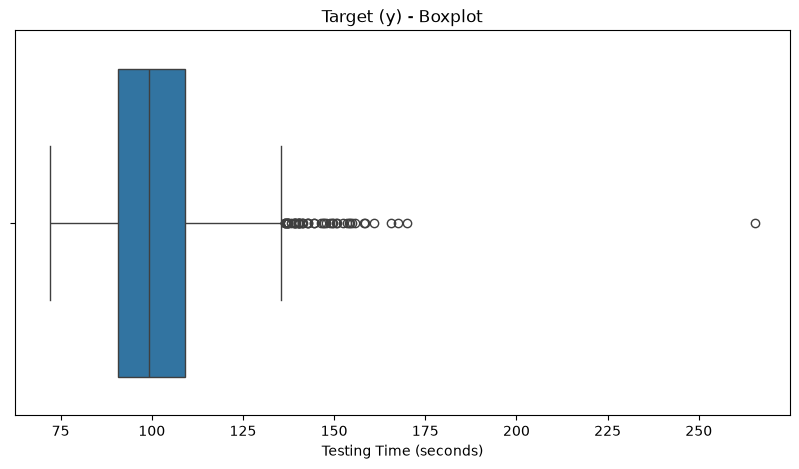

In [31]:
plt.figure(figsize=(10, 5))

sns.boxplot(x=train["y"])

plt.title("Target (y) - Boxplot")
plt.xlabel("Testing Time (seconds)")

plt.show()

In [33]:
Q1 = train["y"].quantile(0.25)
Q3 = train["y"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = train[
    (train["y"] < lower_bound) |
    (train["y"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of outliers:", len(outliers))

outliers[["ID", "y"]].sort_values("y", ascending=False).head(20)


Q1: 90.82
Q3: 109.01
IQR: 18.190000000000012
Lower Bound: 63.534999999999975
Upper Bound: 136.29500000000002
Number of outliers: 50


,ID,y
883,1770,265.32
342,681,169.91
1459,2903,167.45
3133,6273,165.52
1203,2396,160.87
889,1784,158.53
2735,5471,158.23
3744,7500,155.62
429,836,154.87
1060,2111,154.43


In [34]:
num_features = train.select_dtypes(include=np.number).columns.drop(["ID", "y"])

non_binary = [
    col for col in num_features
    if train[col].nunique() > 2
]

print("Non-binary numerical features:", len(non_binary))
print(non_binary)


Non-binary numerical features: 0
[]


50 قيمة متطرفة حسب IQR، لكن مش هنحذفها حاليًا لأنها ممكن تكون حالات حقيقية ومهمة للموديل.

دلوقتي أعتقد نعمل EDA للـ Categorical Features

In [35]:
for col in train.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(train[col].value_counts().head(10))


X0
X0
z     360
ak    349
y     324
ay    313
t     306
x     300
o     269
f     227
n     195
w     182
Name: count, dtype: int64

X1
X1
aa    833
s     598
b     592
l     590
v     408
r     251
i     203
a     143
c     121
o      82
Name: count, dtype: int64

X2
X2
as    1659
ae     496
ai     415
m      367
ak     265
r      153
n      137
s       94
f       87
e       81
Name: count, dtype: int64

X3
X3
c    1942
f    1076
a     440
d     290
g     241
e     163
b      57
Name: count, dtype: int64

X4
X4
d    4205
a       2
b       1
c       1
Name: count, dtype: int64

X5
X5
v    231
w    231
q    220
r    215
d    214
s    214
n    212
m    208
p    208
i    207
Name: count, dtype: int64

X6
X6
g    1042
j    1039
d     625
i     488
l     478
a     206
h     190
k      43
c      38
b      28
Name: count, dtype: int64

X8
X8
j    277
s    255
f    243
n    242
i    237
e    225
r    219
a    210
w    196
v    194
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_10100\1701968999.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in train.select_dtypes(include="object").columns:


In [36]:
categorical_features = train.select_dtypes(include="object").columns

for col in categorical_features:
    print(f"{col}: {train[col].nunique()} unique values")

X0: 47 unique values
X1: 27 unique values
X2: 44 unique values
X3: 7 unique values
X4: 4 unique values
X5: 29 unique values
X6: 12 unique values
X8: 25 unique values


C:\Users\HP\AppData\Local\Temp\ipykernel_10100\2950048424.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include="object").columns


In [37]:
categorical_features = train.select_dtypes(include="object").columns

for col in categorical_features:
    counts = train[col].value_counts()
    
    print(f"\n{col}")
    print("Minimum frequency:", counts.min())
    print("Rare categories (<= 5 occurrences):")
    print(counts[counts <= 5])


X0
Minimum frequency: 1
Rare categories (<= 5 occurrences):
X0
ao    4
c     3
q     2
aa    2
ac    1
g     1
ab    1
Name: count, dtype: int64

X1
Minimum frequency: 3
Rare categories (<= 5 occurrences):
X1
d     3
q     3
ab    3
Name: count, dtype: int64

X2
Minimum frequency: 1
Rare categories (<= 5 occurrences):
X2
al    5
an    5
q     5
av    4
ah    4
p     4
au    3
am    1
j     1
af    1
l     1
aa    1
c     1
o     1
ar    1
Name: count, dtype: int64

X3
Minimum frequency: 57
Rare categories (<= 5 occurrences):
Series([], Name: count, dtype: int64)

X4
Minimum frequency: 1
Rare categories (<= 5 occurrences):
X4
a    2
b    1
c    1
Name: count, dtype: int64

X5
Minimum frequency: 1
Rare categories (<= 5 occurrences):
X5
x    2
u    1
y    1
h    1
g    1
Name: count, dtype: int64

X6
Minimum frequency: 12
Rare categories (<= 5 occurrences):
Series([], Name: count, dtype: int64)

X8
Minimum frequency: 100
Rare categories (<= 5 occurrences):
Series([], Name: count, dtype: 

C:\Users\HP\AppData\Local\Temp\ipykernel_10100\1513165030.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include="object").columns


إحنا عرفنا توزيع الـ Categories، لكن لسه مش عرفنا:

هل الـ Categories دي فعلًا بتأثر على Testing Time y؟

In [39]:
categorical_features = train.select_dtypes(include="object").columns

for col in categorical_features:
    summary = (
        train.groupby(col)["y"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n{'='*50}")
    print(f"{col}")
    print(summary.head(10)) 
    #متوسط زمن الاختبار لكل Category.
    


X0
          mean   median  count
X0                            
aa  152.170000  152.170      2
au  118.695455  116.410     11
ap  116.577864  115.130    103
a   115.630952  113.800     21
as  115.349000  113.645     10
r   113.914000  113.140     10
at  113.465200  111.010     25
af  112.791143  112.750     35
w   112.614121  110.010    182
x   112.555333  109.740    300

X1
          mean   median  count
X1                            
e   107.337879  107.610     33
k   106.800000  107.450     17
i   105.727488  105.400    203
p   105.568889  108.210      9
f   104.522609   99.680     23
h   103.672759  106.020     29
g   103.191667  105.290      6
m   102.788750  107.785     32
j   102.489545  101.900     22
n   102.463158  105.030     19

X2
          mean   median  count
X2                            
aa  146.300000  146.300      1
ar  131.980000  131.980      1
am  122.510000  122.510      1
s   116.977447  115.395     94
k   114.950400  111.420     25
al  113.362000  112.490    

C:\Users\HP\AppData\Local\Temp\ipykernel_10100\659493874.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include="object").columns


من هنا عرفنا ان 

 categorical features الـ

targetليها علاقة بالـ 

 مختلف للعربيه configuration ده منطقي جدًا لأن 

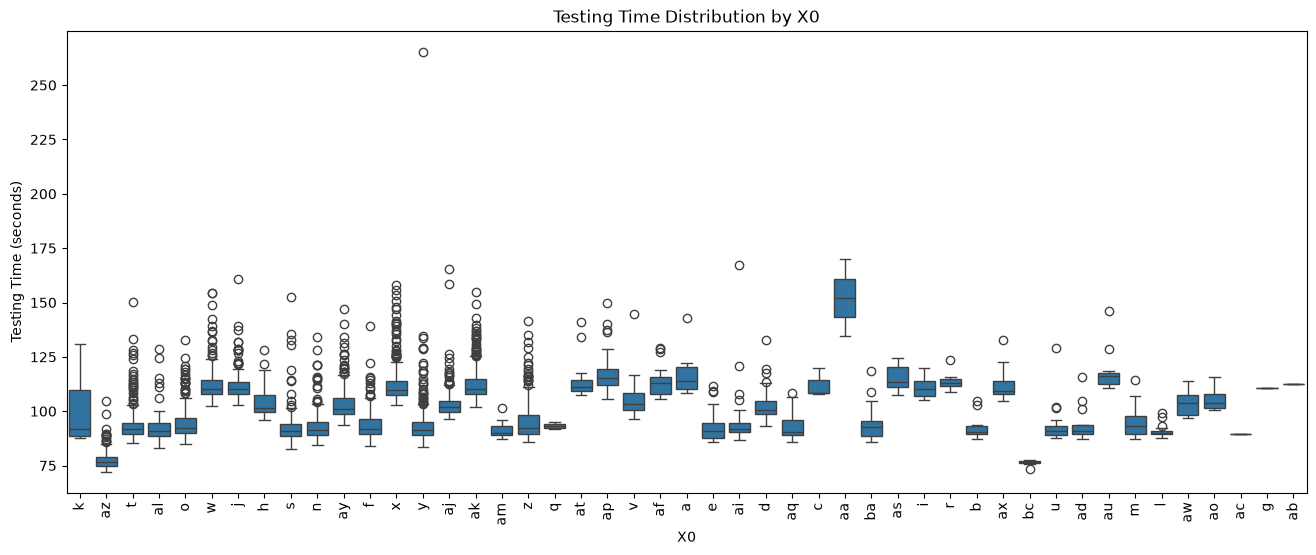

In [40]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=train,
    x="X0",
    y="y"
)

plt.title("Testing Time Distribution by X0")
plt.xlabel("X0")
plt.ylabel("Testing Time (seconds)")
plt.xticks(rotation=90)

plt.show()

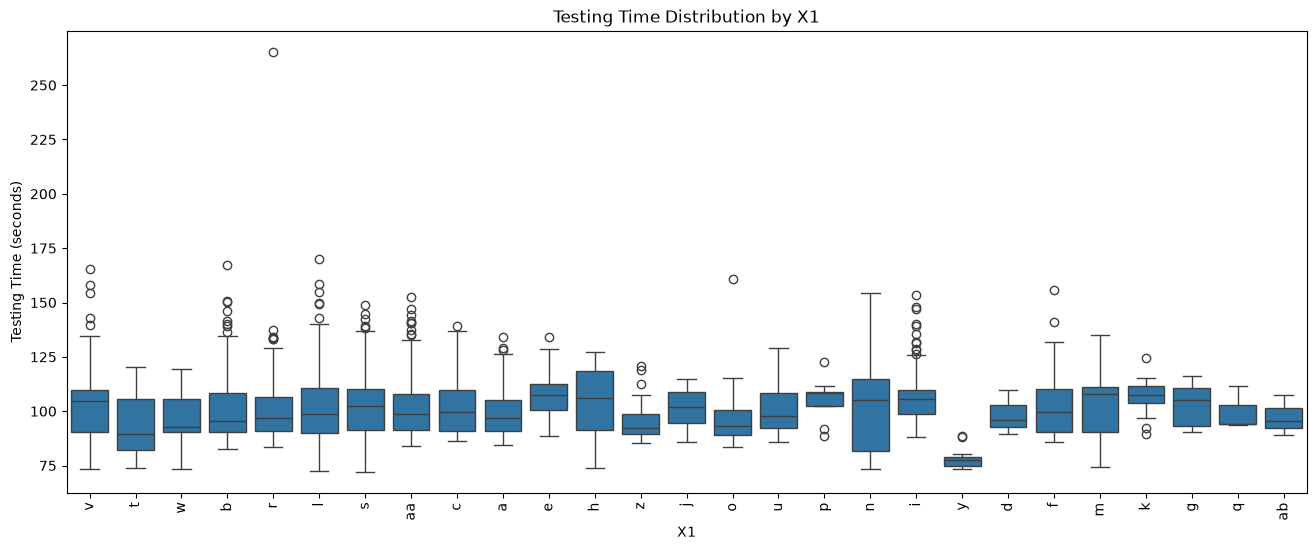

In [41]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=train,
    x="X1",
    y="y"
)

plt.title("Testing Time Distribution by X1")
plt.xlabel("X1")
plt.ylabel("Testing Time (seconds)")
plt.xticks(rotation=90)

plt.show()

وبالمناسبة، اللي ظهر في X0 يخلي عندنا سبب قوي إن الـ categorical features دي ما تتشالش أثناء الـ cleaning لمجرد إنها نصوص؛ هي بالفعل ممكن تحمل معلومات مهمة للتنبؤ.


هنشوف الـ Binary Numerical Features هل توزيع الـ 0/1 فيها متوازن ولا فيه أعمدة شبه فاضية.


In [42]:
binary_features = [
    col for col in train.columns
    if col not in ["ID", "y"] and train[col].nunique() == 2
]

binary_ratio = pd.DataFrame({
    "Feature": binary_features,
    "Mean": train[binary_features].mean(),
    "Count_1": train[binary_features].sum(),
    "Percent_1": train[binary_features].mean() * 100
})

binary_ratio = binary_ratio.sort_values("Percent_1")

binary_ratio.head(15)

,Feature,Mean,Count_1,Percent_1
X39,X39,0.000238,1,0.023759
X33,X33,0.000238,1,0.023759
X42,X42,0.000238,1,0.023759
X339,X339,0.000238,1,0.023759
X296,X296,0.000238,1,0.023759
X295,X295,0.000238,1,0.023759
X288,X288,0.000238,1,0.023759
X280,X280,0.000238,1,0.023759
X95,X95,0.000238,1,0.023759
X204,X204,0.000238,1,0.023759


In [43]:
binary_ratio.tail(15)

,Feature,Mean,Count_1,Percent_1
X304,X304,0.924210,3890,92.421003
X101,X101,0.935614,3938,93.561416
X98,X98,0.942504,3967,94.250416
X80,X80,0.947018,3986,94.701829
X348,X348,0.947256,3987,94.725588
X61,X61,0.953908,4015,95.390829
X136,X136,0.956522,4026,95.652174
X263,X263,0.956997,4028,95.699691
X120,X120,0.957710,4031,95.770967
X128,X128,0.958422,4034,95.842243


دلوقتي عايزنا نشوف هل الـ 

Binary Features دي فعلًا مرتبطة بالـ y.

In [45]:
binary_features = [
    col for col in train.columns
    if col not in ["ID", "y"] and train[col].nunique() == 2
]

results = []

for col in binary_features:
    count_1 = train[col].sum()
    percent_1 = train[col].mean() * 100

    mean_0 = train.loc[train[col] == 0, "y"].mean()
    mean_1 = train.loc[train[col] == 1, "y"].mean()

    results.append({
        "Feature": col,
        "Count_1": count_1,
        "Percent_1": percent_1,
        "Mean_y_when_0": mean_0,
        "Mean_y_when_1": mean_1,
        "Difference": abs(mean_1 - mean_0)
    })

binary_target_analysis = (
    pd.DataFrame(results)
    .sort_values("Difference", ascending=False)
)

binary_target_analysis.head(20)

,Feature,Count_1,Percent_1,Mean_y_when_0,Mean_y_when_1,Difference
311,X339,1,0.023759,100.652864,169.910000,69.257136
215,X236,2,0.047517,100.644835,152.170000,51.525165
185,X204,1,0.023759,100.662155,130.810000,30.147845
186,X205,4208,99.976241,130.810000,100.662155,30.147845
248,X270,1,0.023759,100.675245,75.730000,24.945245
150,X167,4,0.095034,100.692771,76.015000,24.677771
255,X277,6,0.142552,100.704256,76.195000,24.509256
256,X278,2,0.047517,100.680758,76.605000,24.075758
247,X269,2,0.047517,100.680689,76.750000,23.930689
213,X232,181,4.300309,101.689553,77.964862,23.724691


الحركة دي بتعرفنا مين من الأعمدة الثنائية دي ليه ارتباط وتأثير حقيقي على الـ 

 Target (y)
 
 وده بيفيدنا
(Feature Selection)  جداً في اختيار الميزات 
 
 
ومين ملوش أي تأثير (الفرق بينهم قريب من الصفر)،


 وحذف الأعمدة اللي ملهاش لازمة.

هنبدأ بريبروسسنج 

In [46]:
X = train_clean.drop(columns=["ID", "y"])
y = train_clean["y"]

X_test = test_clean.drop(columns=["ID"])

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

#X_test = بيانات الـ test اللي هنستخدمها في النهاية للتنبؤ


X shape: (4209, 319)
y shape: (4209,)
X_test shape: (4209, 319)


نقسم الـ Train إلى Training و Validation

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (3367, 319)
X_val: (842, 319)
y_train: (3367,)
y_val: (842,)


نتأكد إن أنواع الـ Features لسه زي ما هي


In [48]:
categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

print("Categorical features:", len(categorical_features))
print("Numerical features:", len(numerical_features))

print("\nCategorical:")
print(categorical_features)

Categorical features: 8
Numerical features: 311

Categorical:
['X0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X8']


C:\Users\HP\AppData\Local\Temp\ipykernel_10100\398232541.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = X_train.select_dtypes(include="object").columns.tolist()
numerical_features = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

C:\Users\HP\AppData\Local\Temp\ipykernel_10100\3203773171.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


In [50]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_val shape:", X_val_processed.shape)

Processed X_train shape: (3367, 504)
Processed X_val shape: (842, 504)


الخطوة الجاية: Baseline Model

In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

baseline_model = LinearRegression()

baseline_model.fit(X_train_processed, y_train)

y_val_pred = baseline_model.predict(X_val_processed)

mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2 = r2_score(y_val, y_val_pred)

print("Baseline Linear Regression")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Baseline Linear Regression
MAE : 5.727273273238588
RMSE: 8.359231922162667
R²  : 0.5510646615853844


هنعمل Experiment واضح

هنجرب Lasso

In [52]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

alphas = [0.001, 0.01, 0.1, 0.5, 1, 5, 10]

lasso_results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)

    lasso.fit(X_train_processed, y_train)

    y_pred = lasso.predict(X_val_processed)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    non_zero_features = np.count_nonzero(lasso.coef_)

    lasso_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Non-Zero Features": non_zero_features
    })

lasso_results = pd.DataFrame(lasso_results)

lasso_results.sort_values("RMSE")

c:\py_project\E_T_E_Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.556296e+02, tolerance: 5.454e+01
  model = cd_fast.enet_coordinate_descent(


,Alpha,MAE,RMSE,R2,Non-Zero Features
3,0.500,5.417593,8.040566,0.584640,20
2,0.100,5.364447,8.091337,0.579378,93
1,0.010,5.535131,8.229452,0.564896,281
4,1.000,5.665299,8.252625,0.562442,10
0,0.001,5.718547,8.433868,0.543012,363
5,5.000,8.518188,10.999944,0.222622,1
6,10.000,10.142585,12.476246,-0.000044,0


In [53]:
alphas = np.logspace(-3, 0, 30)

lasso_results = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=20000)

    lasso.fit(X_train_processed, y_train)

    y_pred = lasso.predict(X_val_processed)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    non_zero_features = np.count_nonzero(lasso.coef_)

    lasso_results.append({
        "Alpha": alpha,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Non-Zero Features": non_zero_features
    })

lasso_results = pd.DataFrame(lasso_results)

lasso_results.sort_values("RMSE").head(10)

c:\py_project\E_T_E_Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.618182e+02, tolerance: 5.454e+01
  model = cd_fast.enet_coordinate_descent(
c:\py_project\E_T_E_Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.515197e+02, tolerance: 5.454e+01
  model = cd_fast.enet_coordinate_descent(
c:\py_project\E_T_E_Project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

,Alpha,MAE,RMSE,R2,Non-Zero Features
25,0.385662,5.387918,8.027611,0.585978,22
24,0.303920,5.376864,8.030971,0.585631,26
26,0.489390,5.414005,8.038582,0.584845,20
23,0.239503,5.368147,8.040292,0.584669,36
22,0.188739,5.360237,8.044327,0.584252,45
21,0.148735,5.357648,8.058200,0.582816,58
27,0.621017,5.455188,8.070145,0.581579,12
20,0.117210,5.359657,8.079069,0.580653,74
19,0.092367,5.368294,8.094961,0.579001,102
17,0.057362,5.388111,8.099875,0.578490,136


In [54]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

model_results = []

for name, model in models.items():
    model.fit(X_train_processed, y_train)

    y_pred = model.predict(X_val_processed)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    model_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

model_results_df = (
    pd.DataFrame(model_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

model_results_df

,Model,MAE,RMSE,R2
0,Gradient Boosting,5.333114,8.108587,0.577583
1,Ridge,5.694111,8.314581,0.555848
2,Random Forest,5.919072,9.159903,0.460945


Lasso هو الأفضل حاليًا من ناحية RMSE وR²:

أقل RMSE: 8.028
أعلى R²: 0.586
واحتفظ بحوالي 22 Feature فقط من أصل 504 بعد الـ preprocessing.

أما Gradient Boosting فحقق:

أفضل MAE = 5.333
لكنه أسوأ شوية في RMSE وR².

وده طبيعي؛ الـ MAE بيقيس متوسط الخطأ، بينما RMSE بيعاقب الأخطاء الكبيرة بدرجة أكبر.

 القرار الحالي

أنا شايف إننا نركز على Lasso كـ Feature Shrinkage model الأساسي، ونجرب Tuning للـ Gradient Boosting كمان؛ لأن الفرق بينهم قريب، وممكن الـ Gradient Boosting يطلع أحسن بعد الـ tuning.



هنبدأ بـ Tuning للـ Lasso بطريقة صح باستخدام GridSearchCV وCross-Validation، وده هيخلينا نختار الـ alpha على أكتر من split بدل ما نعتمد على Validation واحدة.


In [57]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
import numpy as np

lasso = Lasso(max_iter=15000)

param_grid = {
    "alpha": np.linspace(0.05, 0.80, 50)
}

lasso_grid = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train_processed, y_train)

print("Best Alpha:", lasso_grid.best_params_["alpha"])
print("Best CV RMSE:", -lasso_grid.best_score_)

Best Alpha: 0.14183673469387753
Best CV RMSE: 8.59702455379129


نشوف أداء الـ Best Lasso على الـ Validation

In [58]:
best_lasso = lasso_grid.best_estimator_

y_val_lasso = best_lasso.predict(X_val_processed)

lasso_mae = mean_absolute_error(y_val, y_val_lasso)
lasso_rmse = np.sqrt(mean_squared_error(y_val, y_val_lasso))
lasso_r2 = r2_score(y_val, y_val_lasso)

non_zero_features = np.count_nonzero(best_lasso.coef_)

print("Validation Results")
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)
print("R2:", lasso_r2)
print("Non-Zero Features:", non_zero_features)

Validation Results
MAE: 5.35711500237487
RMSE: 8.061626041925386
R2: 0.5824616791481052
Non-Zero Features: 62


In [60]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    random_state=42
)

param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}

gbr_grid = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

gbr_grid.fit(X_train_processed, y_train)

print("Best Parameters:")
print(gbr_grid.best_params_)

print("Best CV RMSE:")
print(-gbr_grid.best_score_)

Best Parameters:
{'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100}
Best CV RMSE:
8.454569745333657


In [61]:
best_gbr = gbr_grid.best_estimator_

y_val_gbr = best_gbr.predict(X_val_processed)

gbr_mae = mean_absolute_error(y_val, y_val_gbr)
gbr_rmse = np.sqrt(mean_squared_error(y_val, y_val_gbr))
gbr_r2 = r2_score(y_val, y_val_gbr)

print("Gradient Boosting Validation Results")
print("MAE:", gbr_mae)
print("RMSE:", gbr_rmse)
print("R2:", gbr_r2)

Gradient Boosting Validation Results
MAE: 5.246409332165029
RMSE: 7.873171098033165
R2: 0.6017549169598526


PCA


In [62]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_processed)
X_val_pca = pca.transform(X_val_processed)

print("Original features:", X_train_processed.shape[1])
print("PCA components:", X_train_pca.shape[1])

print("Explained variance:", pca.explained_variance_ratio_.sum())

Original features: 504
PCA components: 151
Explained variance: 0.9508917798688423


In [63]:
from sklearn.linear_model import Ridge

pca_model = Ridge(alpha=1.0)

pca_model.fit(X_train_pca, y_train)

y_val_pca = pca_model.predict(X_val_pca)

pca_mae = mean_absolute_error(y_val, y_val_pca)
pca_rmse = np.sqrt(mean_squared_error(y_val, y_val_pca))
pca_r2 = r2_score(y_val, y_val_pca)

print("PCA + Ridge")
print("MAE:", pca_mae)
print("RMSE:", pca_rmse)
print("R2:", pca_r2)

PCA + Ridge
MAE: 5.569770777486011
RMSE: 8.255061134391505
R2: 0.5621839977053693


المرحله الاخيرة قبل الديبلومنت 

In [64]:
X_full = train_clean.drop(columns=["ID", "y"])
y_full = train_clean["y"]

X_test_final = test_clean.drop(columns=["ID"])

print("X_full:", X_full.shape)
print("y_full:", y_full.shape)
print("X_test_final:", X_test_final.shape)

X_full: (4209, 319)
y_full: (4209,)
X_test_final: (4209, 319)


In [65]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = X_full.select_dtypes(include="object").columns.tolist()
numerical_features = X_full.select_dtypes(exclude="object").columns.tolist()

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

X_full_processed = final_preprocessor.fit_transform(X_full)
X_test_processed = final_preprocessor.transform(X_test_final)

print("Final processed train shape:", X_full_processed.shape)
print("Final processed test shape:", X_test_processed.shape)

C:\Users\HP\AppData\Local\Temp\ipykernel_10100\2149870150.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_full.select_dtypes(include="object").columns.tolist()


Final processed train shape: (4209, 506)
Final processed test shape: (4209, 506)


In [66]:
from sklearn.ensemble import GradientBoostingRegressor

final_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

final_model.fit(X_full_processed, y_full)

print("Final model trained successfully!")

Final model trained successfully!


In [67]:
test_predictions = final_model.predict(X_test_processed)

print("Number of predictions:", len(test_predictions))
print(test_predictions[:10])

Number of predictions: 4209
[ 83.92348229  98.87356297  83.92348229  79.60626954 111.80483071
  94.06618064 111.80483071  94.55635022 114.58101263  94.55635022]


In [68]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(final_preprocessor, "models/preprocessor.joblib")
joblib.dump(final_model, "models/final_gradient_boosting.joblib")

print("Files saved successfully!")

Files saved successfully!


In [69]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "y_pred": test_predictions
})

submission.to_csv("test_predictions.csv", index=False)

print("Prediction file saved successfully!")
print(submission.head())
print("Shape:", submission.shape)

Prediction file saved successfully!
   ID      y_pred
0   1   83.923482
1   2   98.873563
2   3   83.923482
3   4   79.606270
4   5  111.804831
Shape: (4209, 2)


In [70]:
print("Model exists:", os.path.exists("models/final_gradient_boosting.joblib"))
print("Preprocessor exists:", os.path.exists("models/preprocessor.joblib"))
print("Prediction file exists:", os.path.exists("test_predictions.csv"))

Model exists: True
Preprocessor exists: True
Prediction file exists: True
